# 2026.9.18(금) 20h~

In [1]:
# 딥러닝 구동하는 데 필요한 Keras 함수 호출
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

2026-09-18 20:16:38.380124: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [3]:
import numpy as np
import tensorflow as tf

In [12]:
np.random.seed(3)
tf.random.set_seed(3)

In [13]:
Data_set = np.loadtxt("ThoraricSurgery.csv", delimiter=",")

In [14]:
X = Data_set[:,0:17]
Y = Data_set[:,17]

In [15]:
model = Sequential()
model.add(Dense(30, input_dim=17, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

In [16]:
model.compile(loss='mean_squared_error', optimizer='adam', metrics=['accuracy'])
model.fit(X, Y, epochs=100, batch_size=10)

Epoch 1/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.7085 - loss: 0.2785 
Epoch 2/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8511 - loss: 0.1485   
Epoch 3/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8489 - loss: 0.1486
Epoch 4/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8489 - loss: 0.1488 
Epoch 5/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.8489 - loss: 0.1488
Epoch 6/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8468 - loss: 0.1486  
Epoch 7/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.8489 - loss: 0.1484
Epoch 8/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8489 - loss: 0.1482 
Epoch 9/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8489 - loss: 0.1479  
Epoch 10/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8489 - loss: 0.1477 
Epoch 11/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8489 - loss: 0.1475 
Epoch 12/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/s

오차 = 실제 값과 예측 값의 차이

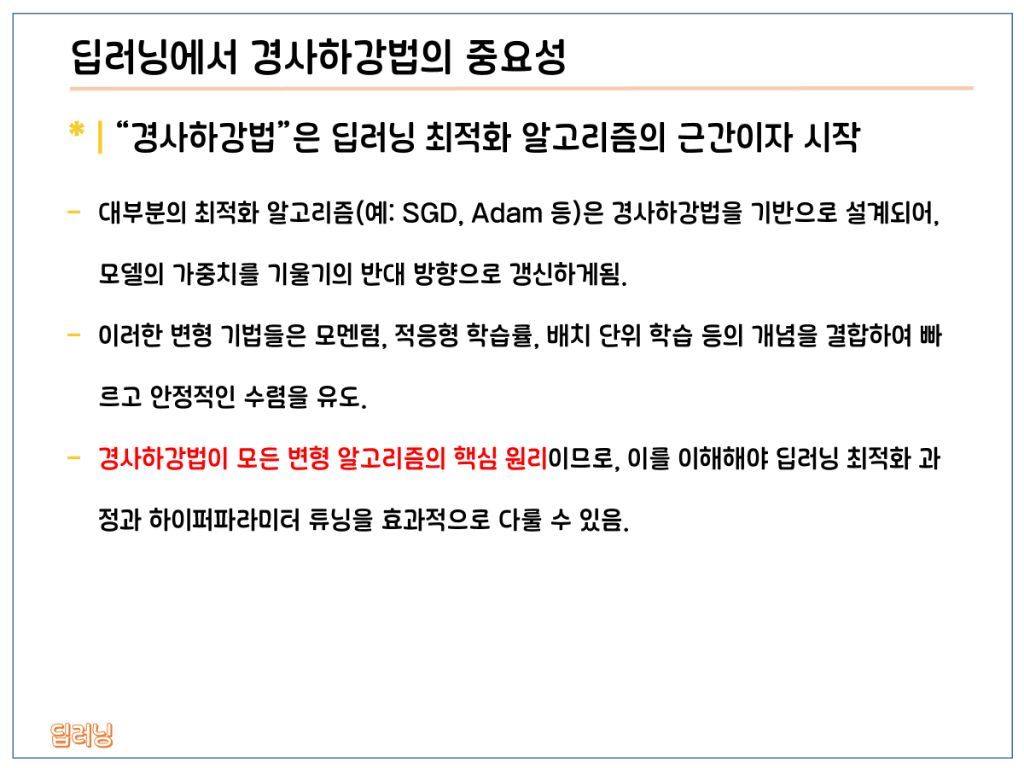

"딥러닝에서 경사하강법의 중요성" 슬라이드에서 '대부분의 최적화 알고리즘은 경사하강법을 기반으로 설계되어, 모델의 가중치를 기울기의 반대 방향으로 갱신하게 됨'이라는 문구가 있는데..

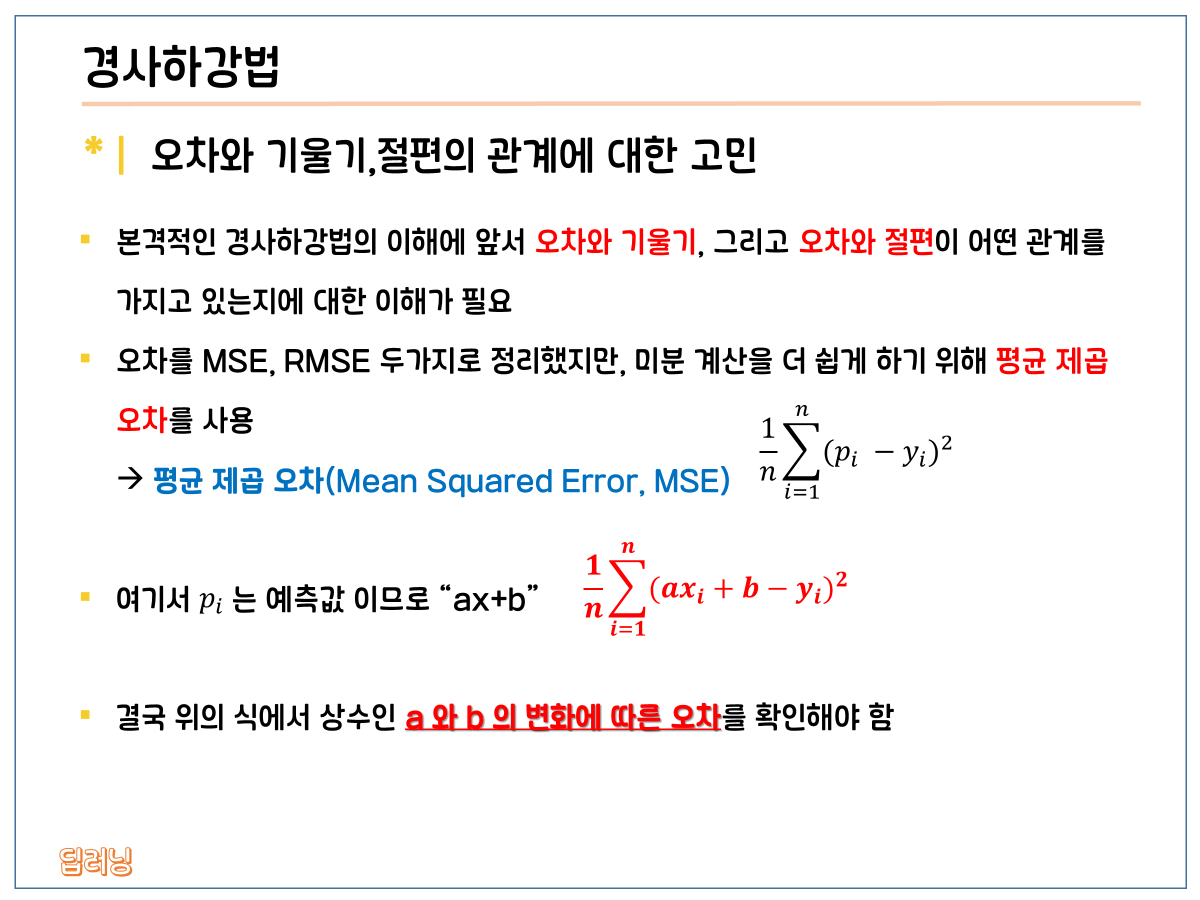

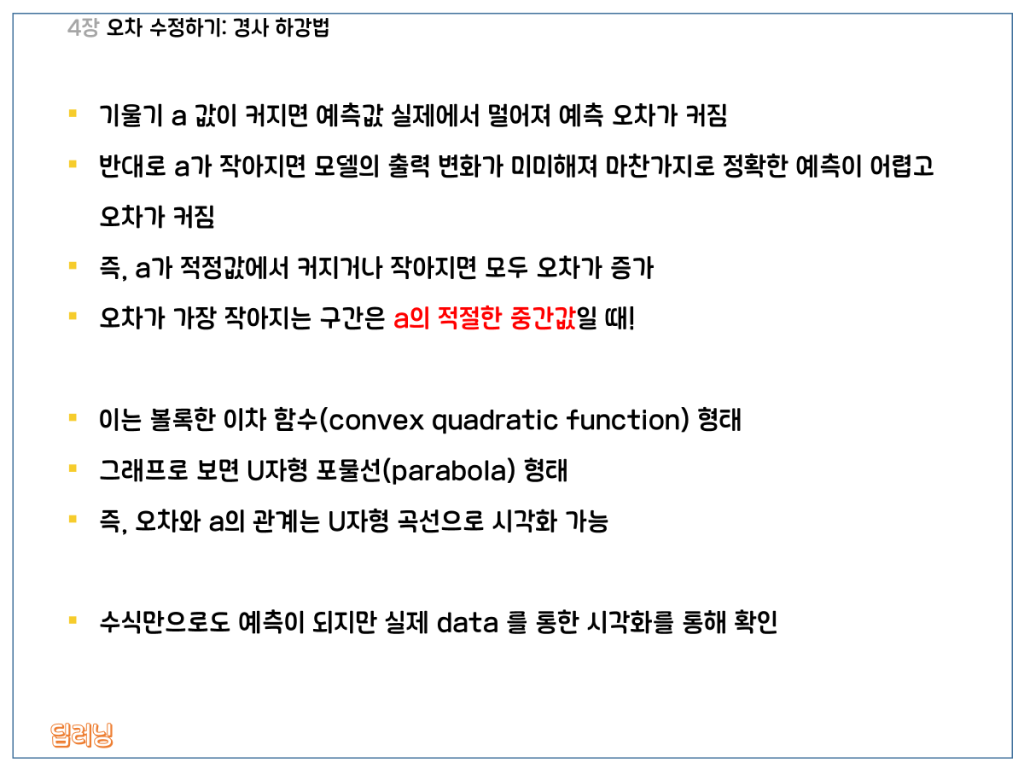

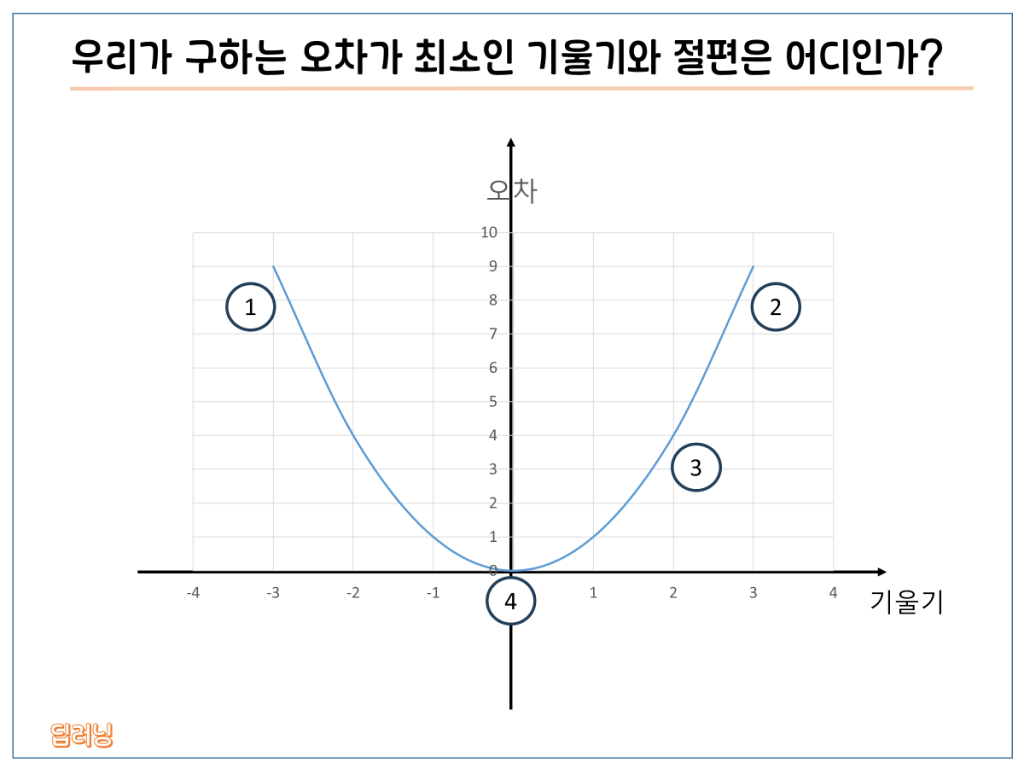

4

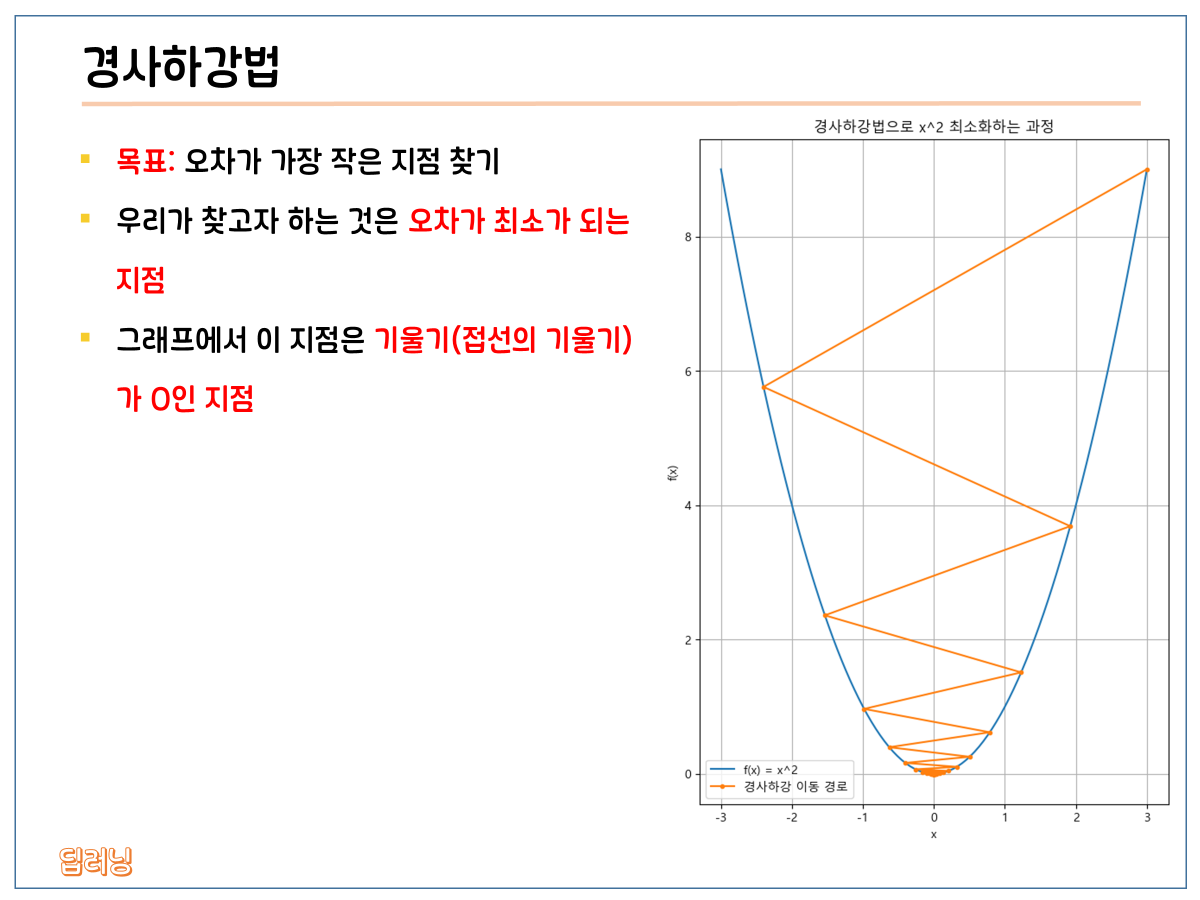

학습률 = 1보다 작은 실수

1. 선형회귀에서 계수 a와 절편 b는 무엇을 의미하나요? => 선형회귀에서 계수 a는 독립변수와 종속변수의 관계를 설명하는 값, 절편 b는 오차?이다 => 강사님 답변: 선형회귀에서 a는 입력에 대한 기울기(영향도), b는 출력의 시작값(절편)을 의미

2-가. 딥러닝에서 모델의 목적은 무엇인가? => 딥러닝에서 모델의 목적은 오차를 가장 작게 하는 a, b를 찾는 것이다 => 강사님 답변: 예측 값이 실제 값과 최대한 가까워지도록 하는 것, 오차의 최소화

2-나. 실제 값과 예측 값의 차이를 어떻게 해석하나요? => 실제 값과 예측 값의 차이는 MSE로 해석한다. a, b가 변할 때 MSE가 어떻게 변하는지를 살펴보면 아래로 오목한 포물선(2차 방정식 그래프)의 관계를 가진다 => 강사님 답변: 예측 값과 실제 값의 차이인 오차는 모델의 성능을 나타내며, 오차를 줄이는 것이 핵심

2-다. 이 차이와 a, b의 관계 및 이를 구현하기 위한 경사하강법의 개념은 무엇인가요? => 이 포물선 관계에서 MSE(오차)가 가장 작아지는 a, b를 찾기/구현하기 위해 경사하강법이 적용되는데, 경사하강법은 임의의 a, b로부터 해당 점에서의 접선의 기울기를 빼며 점점 오차가 작아지는 지점으로 하강 이동하는 것이다 => 강사님 답변: 오차가 크면 a와 b를 조정해가며 모델을 다시 학습시켜야 함. 경사하강법은 오차를 최소화하도록 a, b를 반복적으로 업데이트하는 최적화 알고리즘

### 경사하강법 simulation

In [3]:
import sys
print(sys.executable)

/opt/anaconda3/envs/voice-ai/bin/python


In [4]:
!{sys.executable} -m pip install matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 25.3 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 19.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 28.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [matplotlib]7 [matplotlib]


Matplotlib is building the font cache; this may take a moment.


초기값: x = 3.0000, f(x) = 9.0000
Iteration 1: x = -2.4000, gradient = 6.0000, f(x) = 5.7600
Iteration 2: x = 1.9200, gradient = -4.8000, f(x) = 3.6864
Iteration 3: x = -1.5360, gradient = 3.8400, f(x) = 2.3593
Iteration 4: x = 1.2288, gradient = -3.0720, f(x) = 1.5099
Iteration 5: x = -0.9830, gradient = 2.4576, f(x) = 0.9664
Iteration 6: x = 0.7864, gradient = -1.9661, f(x) = 0.6185
Iteration 7: x = -0.6291, gradient = 1.5729, f(x) = 0.3958
Iteration 8: x = 0.5033, gradient = -1.2583, f(x) = 0.2533
Iteration 9: x = -0.4027, gradient = 1.0066, f(x) = 0.1621
Iteration 10: x = 0.3221, gradient = -0.8053, f(x) = 0.1038
Iteration 11: x = -0.2577, gradient = 0.6442, f(x) = 0.0664
Iteration 12: x = 0.2062, gradient = -0.5154, f(x) = 0.0425
Iteration 13: x = -0.1649, gradient = 0.4123, f(x) = 0.0272
Iteration 14: x = 0.1319, gradient = -0.3299, f(x) = 0.0174
Iteration 15: x = -0.1056, gradient = 0.2639, f(x) = 0.0111
Iteration 16: x = 0.0844, gradient = -0.2111, f(x) = 0.0071
Iteration 17: x = 

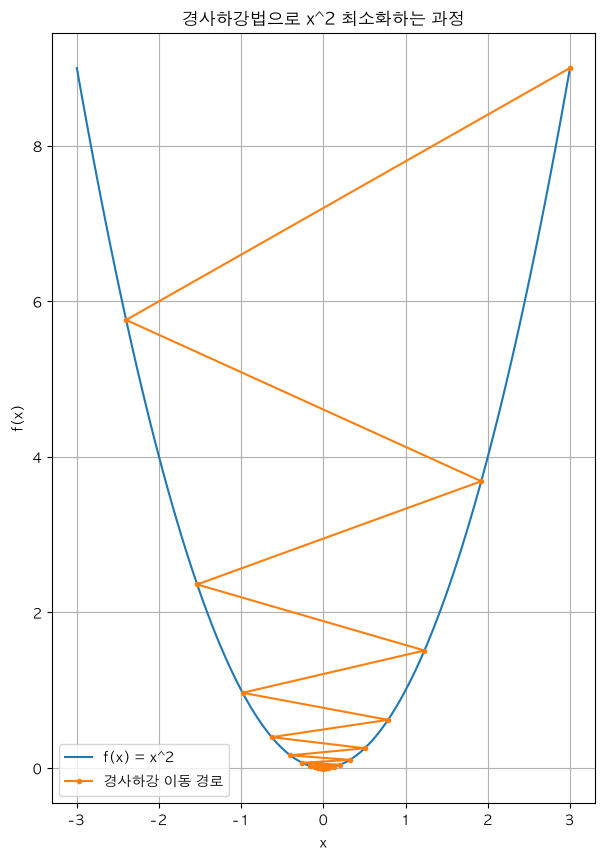

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import font_manager,rc
import platform

 # 한글 폰트 설정
if platform.system() == 'Windows':# 윈도우인 경우
    font_path = "c:/Windows/Fonts/malgun.ttf" # 맑은 고딕 폰트 경로
    font_name = font_manager.FontProperties(fname=font_path).get_name()
    plt.rc('font', family=font_name)
elif platform.system() == 'Darwin': # macOS인 경우
    plt.rc('font', family='AppleGothic')
else: # Linux 등 다른 OS인 경우
    plt.rc('font', family='NanumGothic')
 # 음수 기호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

# 1. 이차 함수와 그 미분 정의
def f(x):
    return x**2

def df(x):
    return 2*x

# 2. 초기값과 학습률 설정
x = 3.0            # 시작점
alpha = 0.9        # 최적 학습률
#alpha = 1.1        # 발산 학습률
#alpha = 0.99        # 미적 학습률
num_iterations = 50  # 반복 횟수

# 결과 기록용 리스트
x_history = [x]
f_history = [f(x)]

print(f"초기값: x = {x:.4f}, f(x) = {f(x):.4f}")

# 3. 경사하강법 반복
for i in range(num_iterations):
    gradient = df(x)
    x = x - alpha * gradient  # x 업데이트
    x_history.append(x)
    f_history.append(f(x))
    
    print(f"Iteration {i+1}: x = {x:.4f}, gradient = {gradient:.4f}, f(x) = {f(x):.4f}")

# 4. 함수 그래프와 이동 경로 시각화
# x 범위 설정(-4 ~ 4 정도로 넉넉하게)
x_vals = np.linspace(-3, 3, 100)
y_vals = f(x_vals)

plt.figure(figsize=(7,10))
plt.plot(x_vals, y_vals, label="f(x) = x^2")

# 경사하강법으로 이동한 지점들 표시
plt.plot(x_history, f_history, '.-', label="경사하강 이동 경로")

plt.title("경사하강법으로 x^2 최소화하는 과정")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.legend()
plt.grid(True)
plt.show()

초기값: x = 3.0000, f(x) = 9.0000
Iteration 1: x = -1.8000, gradient = 6.0000, f(x) = 3.2400
Iteration 2: x = 1.0800, gradient = -3.6000, f(x) = 1.1664
Iteration 3: x = -0.6480, gradient = 2.1600, f(x) = 0.4199
Iteration 4: x = 0.3888, gradient = -1.2960, f(x) = 0.1512
Iteration 5: x = -0.2333, gradient = 0.7776, f(x) = 0.0544
Iteration 6: x = 0.1400, gradient = -0.4666, f(x) = 0.0196
Iteration 7: x = -0.0840, gradient = 0.2799, f(x) = 0.0071
Iteration 8: x = 0.0504, gradient = -0.1680, f(x) = 0.0025
Iteration 9: x = -0.0302, gradient = 0.1008, f(x) = 0.0009
Iteration 10: x = 0.0181, gradient = -0.0605, f(x) = 0.0003
Iteration 11: x = -0.0109, gradient = 0.0363, f(x) = 0.0001
Iteration 12: x = 0.0065, gradient = -0.0218, f(x) = 0.0000
Iteration 13: x = -0.0039, gradient = 0.0131, f(x) = 0.0000
Iteration 14: x = 0.0024, gradient = -0.0078, f(x) = 0.0000
Iteration 15: x = -0.0014, gradient = 0.0047, f(x) = 0.0000
Iteration 16: x = 0.0008, gradient = -0.0028, f(x) = 0.0000
Iteration 17: x = 

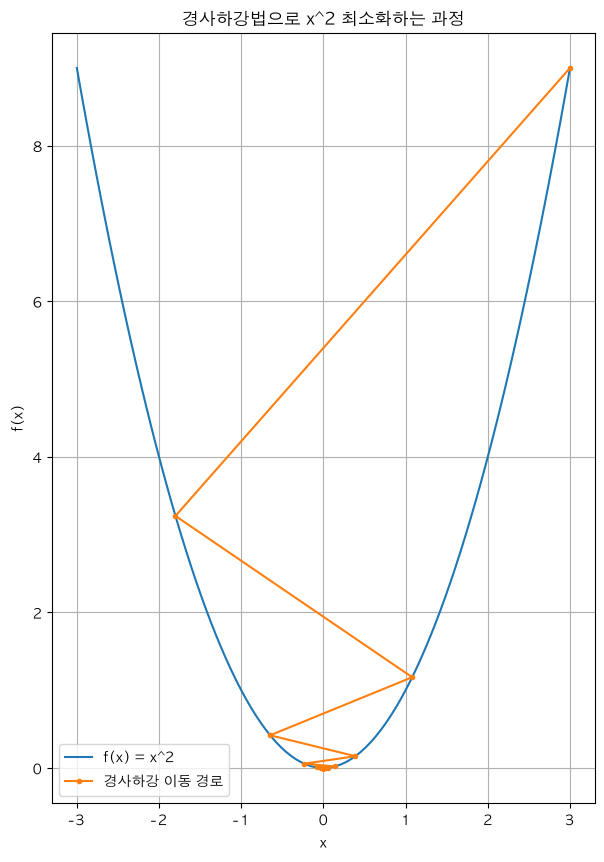

In [8]:
# 2. 초기값과 학습률 설정
x = 3.0            # 시작점
alpha = 0.8        # 최적 학습률 0.9보다 조금 더 작게 해 볼까..
#alpha = 1.1        # 발산 학습률
#alpha = 0.99        # 미적 학습률
num_iterations = 50  # 반복 횟수

# 결과 기록용 리스트
x_history = [x]
f_history = [f(x)]

print(f"초기값: x = {x:.4f}, f(x) = {f(x):.4f}")

# 3. 경사하강법 반복
for i in range(num_iterations):
    gradient = df(x)
    x = x - alpha * gradient  # x 업데이트
    x_history.append(x)
    f_history.append(f(x))
    
    print(f"Iteration {i+1}: x = {x:.4f}, gradient = {gradient:.4f}, f(x) = {f(x):.4f}")

# 4. 함수 그래프와 이동 경로 시각화
# x 범위 설정(-4 ~ 4 정도로 넉넉하게)
x_vals = np.linspace(-3, 3, 100)
y_vals = f(x_vals)

plt.figure(figsize=(7,10))
plt.plot(x_vals, y_vals, label="f(x) = x^2")

# 경사하강법으로 이동한 지점들 표시
plt.plot(x_history, f_history, '.-', label="경사하강 이동 경로")

plt.title("경사하강법으로 x^2 최소화하는 과정")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.legend()
plt.grid(True)
plt.show()

초기값: x = 3.0000, f(x) = 9.0000
Iteration 1: x = -3.6000, gradient = 6.0000, f(x) = 12.9600
Iteration 2: x = 4.3200, gradient = -7.2000, f(x) = 18.6624
Iteration 3: x = -5.1840, gradient = 8.6400, f(x) = 26.8739
Iteration 4: x = 6.2208, gradient = -10.3680, f(x) = 38.6984
Iteration 5: x = -7.4650, gradient = 12.4416, f(x) = 55.7256
Iteration 6: x = 8.9580, gradient = -14.9299, f(x) = 80.2449
Iteration 7: x = -10.7495, gradient = 17.9159, f(x) = 115.5527
Iteration 8: x = 12.8995, gradient = -21.4991, f(x) = 166.3958
Iteration 9: x = -15.4793, gradient = 25.7989, f(x) = 239.6100
Iteration 10: x = 18.5752, gradient = -30.9587, f(x) = 345.0384
Iteration 11: x = -22.2903, gradient = 37.1504, f(x) = 496.8553
Iteration 12: x = 26.7483, gradient = -44.5805, f(x) = 715.4716
Iteration 13: x = -32.0980, gradient = 53.4966, f(x) = 1030.2791
Iteration 14: x = 38.5176, gradient = -64.1959, f(x) = 1483.6020
Iteration 15: x = -46.2211, gradient = 77.0351, f(x) = 2136.3868
Iteration 16: x = 55.4653, gra

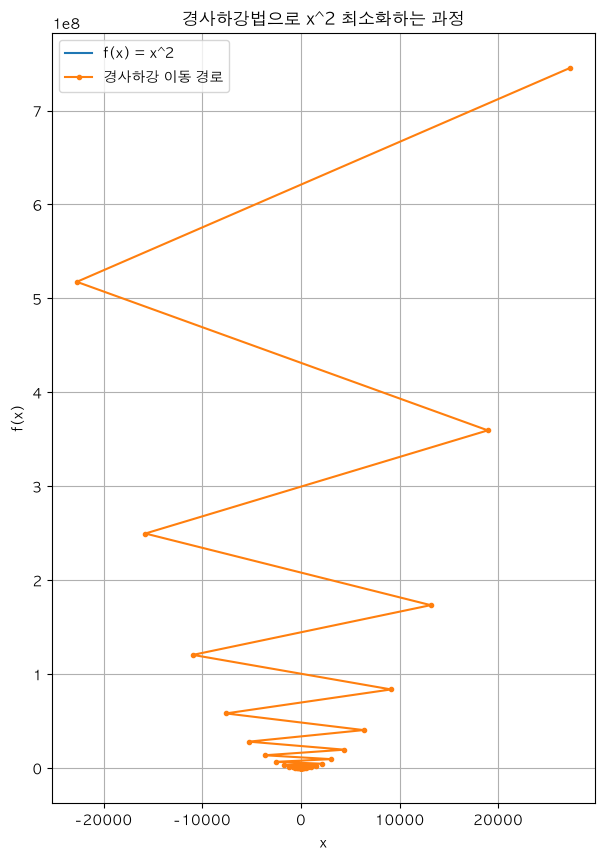

In [6]:
# 2. 초기값과 학습률 설정
x = 3.0            # 시작점
# alpha = 0.9        # 최적 학습률
alpha = 1.1        # 발산 학습률
#alpha = 0.99        # 미적 학습률
num_iterations = 50  # 반복 횟수

# 결과 기록용 리스트
x_history = [x]
f_history = [f(x)]

print(f"초기값: x = {x:.4f}, f(x) = {f(x):.4f}")

# 3. 경사하강법 반복
for i in range(num_iterations):
    gradient = df(x)
    x = x - alpha * gradient  # x 업데이트
    x_history.append(x)
    f_history.append(f(x))
    
    print(f"Iteration {i+1}: x = {x:.4f}, gradient = {gradient:.4f}, f(x) = {f(x):.4f}")

# 4. 함수 그래프와 이동 경로 시각화
# x 범위 설정(-4 ~ 4 정도로 넉넉하게)
x_vals = np.linspace(-3, 3, 100)
y_vals = f(x_vals)

plt.figure(figsize=(7,10))
plt.plot(x_vals, y_vals, label="f(x) = x^2")

# 경사하강법으로 이동한 지점들 표시
plt.plot(x_history, f_history, '.-', label="경사하강 이동 경로")

plt.title("경사하강법으로 x^2 최소화하는 과정")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.legend()
plt.grid(True)
plt.show()

초기값: x = 3.0000, f(x) = 9.0000
Iteration 1: x = -2.9400, gradient = 6.0000, f(x) = 8.6436
Iteration 2: x = 2.8812, gradient = -5.8800, f(x) = 8.3013
Iteration 3: x = -2.8236, gradient = 5.7624, f(x) = 7.9726
Iteration 4: x = 2.7671, gradient = -5.6472, f(x) = 7.6569
Iteration 5: x = -2.7118, gradient = 5.5342, f(x) = 7.3537
Iteration 6: x = 2.6575, gradient = -5.4235, f(x) = 7.0625
Iteration 7: x = -2.6044, gradient = 5.3151, f(x) = 6.7828
Iteration 8: x = 2.5523, gradient = -5.2088, f(x) = 6.5142
Iteration 9: x = -2.5012, gradient = 5.1046, f(x) = 6.2562
Iteration 10: x = 2.4512, gradient = -5.0025, f(x) = 6.0085
Iteration 11: x = -2.4022, gradient = 4.9024, f(x) = 5.7705
Iteration 12: x = 2.3542, gradient = -4.8044, f(x) = 5.5420
Iteration 13: x = -2.3071, gradient = 4.7083, f(x) = 5.3226
Iteration 14: x = 2.2609, gradient = -4.6141, f(x) = 5.1118
Iteration 15: x = -2.2157, gradient = 4.5219, f(x) = 4.9094
Iteration 16: x = 2.1714, gradient = -4.4314, f(x) = 4.7149
Iteration 17: x = 

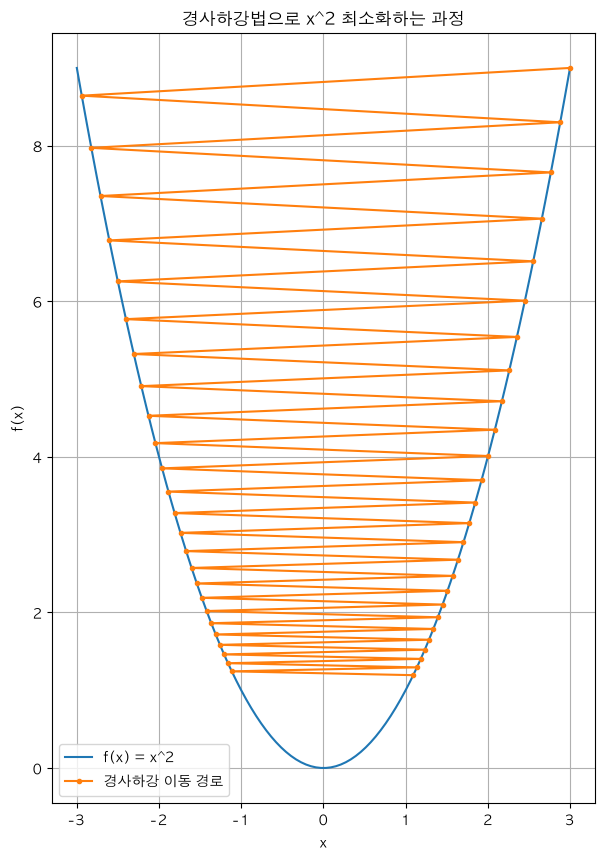

In [7]:
# 2. 초기값과 학습률 설정
x = 3.0            # 시작점
# alpha = 0.9        # 최적 학습률
# alpha = 1.1        # 발산 학습률
alpha = 0.99        # 미적 학습률
num_iterations = 50  # 반복 횟수

# 결과 기록용 리스트
x_history = [x]
f_history = [f(x)]

print(f"초기값: x = {x:.4f}, f(x) = {f(x):.4f}")

# 3. 경사하강법 반복
for i in range(num_iterations):
    gradient = df(x)
    x = x - alpha * gradient  # x 업데이트
    x_history.append(x)
    f_history.append(f(x))
    
    print(f"Iteration {i+1}: x = {x:.4f}, gradient = {gradient:.4f}, f(x) = {f(x):.4f}")

# 4. 함수 그래프와 이동 경로 시각화
# x 범위 설정(-4 ~ 4 정도로 넉넉하게)
x_vals = np.linspace(-3, 3, 100)
y_vals = f(x_vals)

plt.figure(figsize=(7,10))
plt.plot(x_vals, y_vals, label="f(x) = x^2")

# 경사하강법으로 이동한 지점들 표시
plt.plot(x_history, f_history, '.-', label="경사하강 이동 경로")

plt.title("경사하강법으로 x^2 최소화하는 과정")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.legend()
plt.grid(True)
plt.show()

### 22h20~ 중요한 코드

[2, 4, 6, 8] [81, 93, 91, 97]


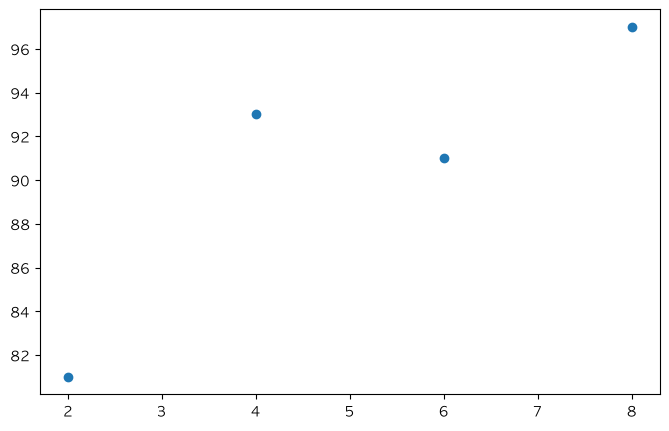

In [11]:
# 공부 시간 x와 성적 y의 리스트를 만들기
data = [[2,81],[4,93],[6,91],[8,97]]
x = [i[0] for i in data]
y = [i[1] for i in data]
# 다루는 데이터는 2차원 배열인 경우 많음 e.g. 오늘 수업 초반부 ThoraricSurgery.csv 파일

# x,y data 확인
print(x,y)

# 그래프로 나타내기
plt.figure(figsize=(8,5))
plt.scatter(x,y)
plt.show()

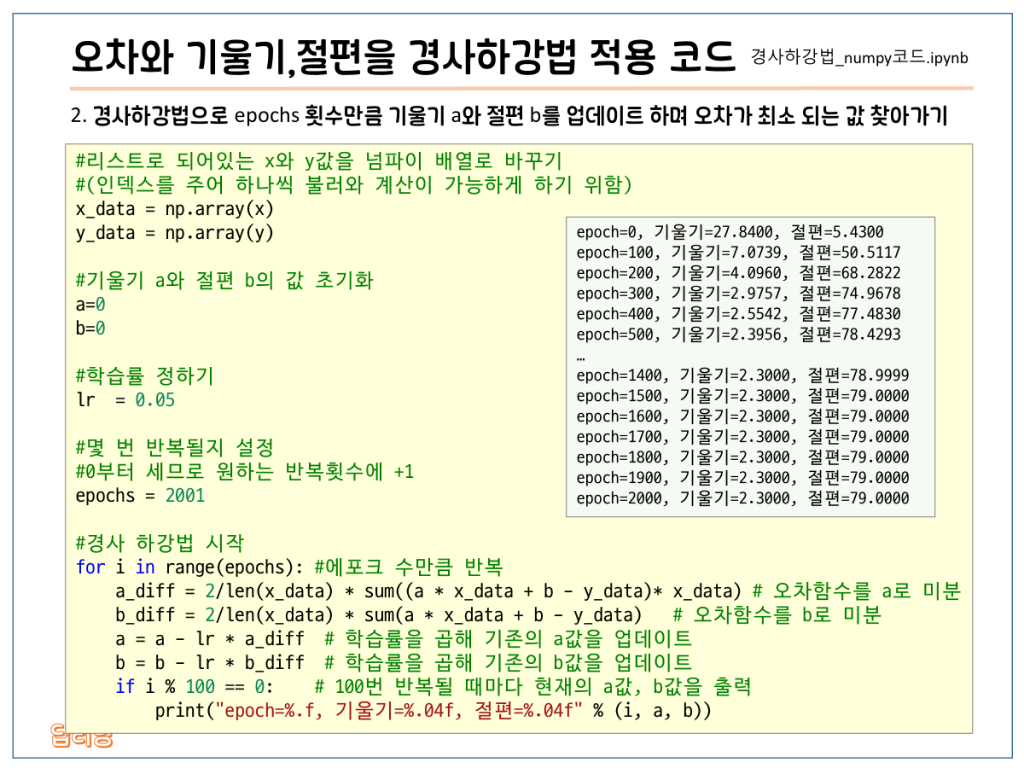

In [12]:
x_data = np.array(x)
y_data = np.array(y)

a = 0
b = 0

lr = 0.05

epochs = 2001

for i in range(epochs):
    a_diff = 2 / len(x_data) * sum((a * x_data + b - y_data) * x_data) # 우리 수업에서는 a의 미분 공식 유도는 하지 않았으나(시간상 생략), a의 미분 값/a에서의 접선의 기울기를 구하는 코드
    b_diff = 2 / len(x_data) * sum(a * x_data + b - y_data)
    a = a - lr * a_diff
    b = b - lr * b_diff
    if i % 100 == 0:
        print("epoch=%.f, 기울기=%.04f, 절편=%.04f" %(i, a, b))

epoch=0, 기울기=46.4000, 절편=9.0500
epoch=100, 기울기=2418478117062402073952133996085248.0000, 절편=405270013216241424840325620301824.0000
epoch=200, 기울기=185719364669233752219629566456254005543684898338709890459244691456.0000, 절편=31121426670353590752218299939770683531479248570440853702934790144.0000
epoch=300, 기울기=14261730205373602513874542029949442679016613603068807701329004847279875738058516589811801222283264.0000, 절편=2389871360853456434489730078568588285448055643469487934952246020631114094776416180349975929028608.0000
epoch=400, 기울기=1095184386469960806303898659279930350408605934250761120486105224484330042950118847408930491069390991042329920491364212239583150080.0000, 절편=183522599459373251461817843978972193007154501343978823689289837966162958770239198437316527548930328309216467586604723234154741760.0000
epoch=500, 기울기=84101215146788670008210403617984337965697431748615875899186257234594377506423721117737161181176225703762004748280914070263250674478115873601798478610706315870208.0000, 절편=140930

/var/folders/y2/5m8dl9kj7yl_xvfwnl0xlj8m0000gn/T/ipykernel_95984/2356138732.py:12: RuntimeWarning: overflow encountered in scalar add
  a_diff = 2 / len(x_data) * sum((a * x_data + b - y_data) * x_data)
/var/folders/y2/5m8dl9kj7yl_xvfwnl0xlj8m0000gn/T/ipykernel_95984/2356138732.py:14: RuntimeWarning: invalid value encountered in scalar subtract
  a = a - lr * a_diff


nan = 값이 너무 작아서 수학적으로 표현할 수 없는 값 등

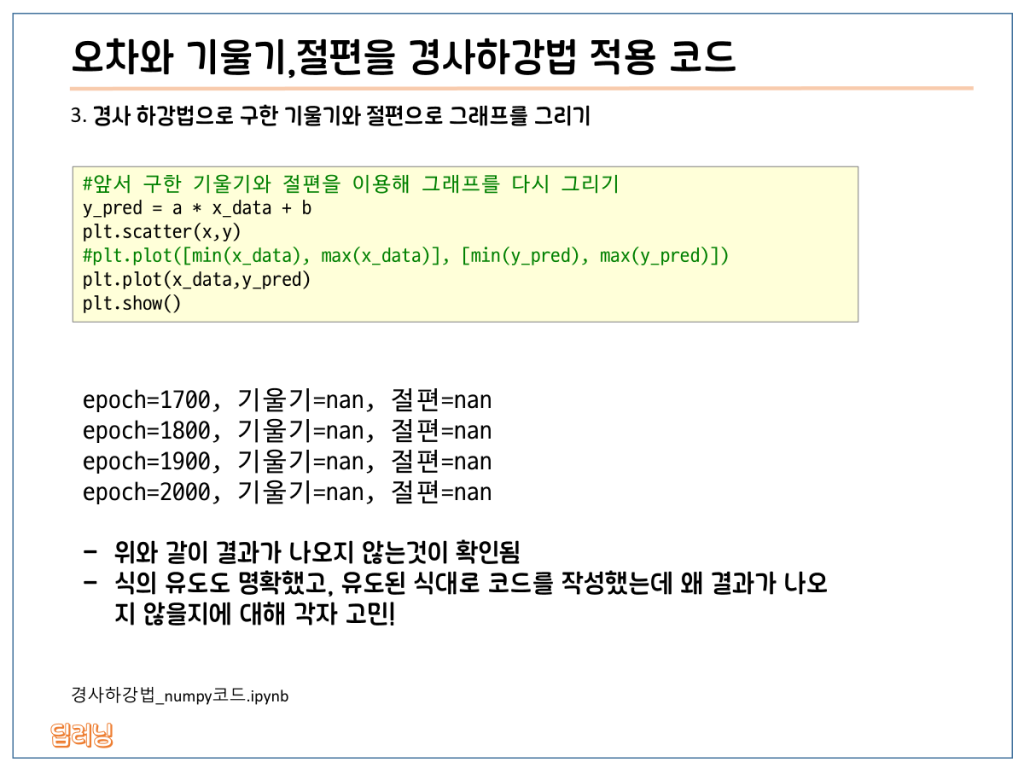

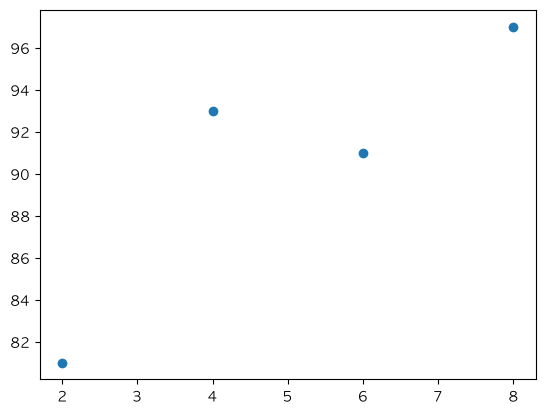

In [14]:
y_pred = a * x_data + b
plt.scatter(x,y)

plt.plot(x_data,y_pred)
plt.show()

epoch=0, 기울기=27.8400, 절편=5.4300
epoch=100, 기울기=7.0739, 절편=50.5117
epoch=200, 기울기=4.0960, 절편=68.2822
epoch=300, 기울기=2.9757, 절편=74.9678
epoch=400, 기울기=2.5542, 절편=77.4830
epoch=500, 기울기=2.3956, 절편=78.4293
epoch=600, 기울기=2.3360, 절편=78.7853
epoch=700, 기울기=2.3135, 절편=78.9192
epoch=800, 기울기=2.3051, 절편=78.9696
epoch=900, 기울기=2.3019, 절편=78.9886
epoch=1000, 기울기=2.3007, 절편=78.9957
epoch=1100, 기울기=2.3003, 절편=78.9984
epoch=1200, 기울기=2.3001, 절편=78.9994
epoch=1300, 기울기=2.3000, 절편=78.9998
epoch=1400, 기울기=2.3000, 절편=78.9999
epoch=1500, 기울기=2.3000, 절편=79.0000
epoch=1600, 기울기=2.3000, 절편=79.0000
epoch=1700, 기울기=2.3000, 절편=79.0000
epoch=1800, 기울기=2.3000, 절편=79.0000
epoch=1900, 기울기=2.3000, 절편=79.0000
epoch=2000, 기울기=2.3000, 절편=79.0000


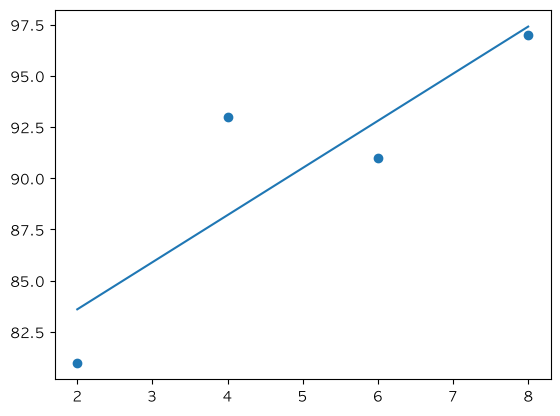

In [28]:
x_data = np.array(x)
y_data = np.array(y)

a = 0
b = 0

lr = 0.03

epochs = 2001

for i in range(epochs):
    a_diff = 2 / len(x_data) * sum((a * x_data + b - y_data) * x_data) # 우리 수업에서는 a의 미분 공식 유도는 하지 않았으나(시간상 생략), a의 미분 값/a에서의 접선의 기울기를 구하는 코드
    b_diff = 2 / len(x_data) * sum(a * x_data + b - y_data)
    a = a - lr * a_diff
    b = b - lr * b_diff
    if i % 100 == 0:
        print("epoch=%.f, 기울기=%.04f, 절편=%.04f" %(i, a, b))

y_pred = a * x_data + b
plt.scatter(x,y)

plt.plot(x_data,y_pred)
plt.show()

epoch=0, 기울기=5.0313, 절편=0.1065
epoch=100, 기울기=7.7213, 절편=0.6859
epoch=200, 기울기=9.6910, 절편=1.1443
epoch=300, 기울기=11.1318, 절편=1.5139
epoch=400, 기울기=12.1843, 절편=1.8181
epoch=500, 기울기=12.9515, 절편=2.0744
epoch=600, 기울기=13.5095, 절편=2.2955
epoch=700, 기울기=13.9136, 절편=2.4905
epoch=800, 기울기=14.2049, 절편=2.6664
epoch=900, 기울기=14.4134, 절편=2.8282
epoch=1000, 기울기=14.5609, 절편=2.9797
epoch=1100, 기울기=14.6639, 절편=3.1234
epoch=1200, 기울기=14.7340, 절편=3.2614
epoch=1300, 기울기=14.7800, 절편=3.3952
epoch=1400, 기울기=14.8084, 절편=3.5259
epoch=1500, 기울기=14.8239, 절편=3.6541
epoch=1600, 기울기=14.8298, 절편=3.7806
epoch=1700, 기울기=14.8287, 절편=3.9057
epoch=1800, 기울기=14.8226, 절편=4.0297
epoch=1900, 기울기=14.8126, 절편=4.1529
epoch=2000, 기울기=14.8000, 절편=4.2754


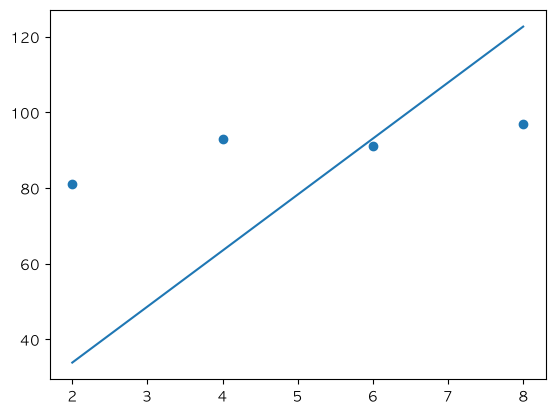

In [29]:
# 나의 실험 <- lr를 더 작게 바꿔보다가.. 결과 어떻게 봐야하는지 모르다가.. a, b 초기값이 이상한 건가 싶어서 바꿔보기도 하고.. epochs 바꿔보기도 하고..
x_data = np.array(x)
y_data = np.array(y)

a = 5
b = 0.1

lr = 0.00005

epochs = 2001

for i in range(epochs):
    a_diff = 2 / len(x_data) * sum((a * x_data + b - y_data) * x_data)
    b_diff = 2 / len(x_data) * sum(a * x_data + b - y_data)
    a = a - lr * a_diff
    b = b - lr * b_diff
    if i % 100 == 0:
        print("epoch=%.f, 기울기=%.04f, 절편=%.04f" %(i, a, b))

y_pred = a * x_data + b
plt.scatter(x,y)

plt.plot(x_data,y_pred)
plt.show()